In [1]:
import random
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from shapely.geometry import Point
from pathlib import Path

random.seed(42)
np.random.seed(42)

print("All imports OK")

All imports OK


In [2]:
# ── Dispatch Center ────────────────────────────────────────────────────────────
ORIGIN_LAT = 40.7589
ORIGIN_LON = -73.9851
ORIGIN_NAME = "Midtown Manhattan"

# ── Mode Parameters ────────────────────────────────────────────────────────────
MODES = {
    'Cargo Bike': {
        'mode_name'             : 'Cargo Bike',
        'max_payload_kg'        : 300,
        'max_parcels_per_day'   : 39,
        'stops_per_trip'        : 13,
        'trips_per_day'         : 3,
        'max_service_radius_km' : 6,
        'speed_kmh'             : 25,
        'parcels_per_stop'      : 1,
        'emission_factor'       : 0.0155,
        'cost_per_km'           : 0.25,
    },
    'E-Van': {
        'mode_name'             : 'E-Van',
        'max_payload_kg'        : 800,
        'max_parcels_per_day'   : 140,
        'stops_per_trip'        : 40,
        'trips_per_day'         : 3,
        'max_service_radius_km' : 30,
        'speed_kmh'             : 50,
        'parcels_per_stop'      : 2,
        'emission_factor'       : 0.1575,
        'cost_per_km'           : 0.70,
    },
    'Truck': {
        'mode_name'             : 'Truck',
        'max_payload_kg'        : 3000,
        'max_parcels_per_day'   : 160,
        'stops_per_trip'        : 25,
        'trips_per_day'         : 1,
        'max_service_radius_km' : 40,
        'speed_kmh'             : 40,
        'parcels_per_stop'      : 3,
        'emission_factor'       : 0.3235,
        'cost_per_km'           : 1.20,
    },
}

# ── Demand Levels for Sweep ────────────────────────────────────────────────────
DEMAND_LEVELS = [25, 50, 75, 100, 125, 150, 175, 200]

print(f"Dispatch center: {ORIGIN_NAME} ({ORIGIN_LAT}, {ORIGIN_LON})")
print(f"Modes: {list(MODES.keys())}")
print(f"Demand levels: {DEMAND_LEVELS}")

Dispatch center: Midtown Manhattan (40.7589, -73.9851)
Modes: ['Cargo Bike', 'E-Van', 'Truck']
Demand levels: [25, 50, 75, 100, 125, 150, 175, 200]


In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Real-world straight-line distance between two lat/lon points in km."""
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Sanity check — Midtown to Financial District
test_dist = haversine_km(ORIGIN_LAT, ORIGIN_LON, 40.7128, -74.0060)
print(f"Midtown → Financial District: {test_dist:.2f} km ✓ (correct, Manhattan is ~21km tip to tip)")

# Additional check — Midtown to JFK (should be ~20km)
test_dist2 = haversine_km(ORIGIN_LAT, ORIGIN_LON, 40.6413, -73.7781)
print(f"Midtown → JFK Airport: {test_dist2:.2f} km ✓ (expect ~20km)")

Midtown → Financial District: 5.42 km ✓ (correct, Manhattan is ~21km tip to tip)
Midtown → JFK Airport: 21.81 km ✓ (expect ~20km)


In [5]:
# ── Section 2: Load All Destination Datasets ──────────────────────────────────
# We load 5 destination types from NYC Open Data.
# Each is cleaned to: geometry (Point), name, dataset_type columns only.
# All converted to GeoDataFrame with CRS EPSG:4326.

def load_nyc_dataset(url, lat_col, lon_col, name_col, dataset_label, limit=50000):
    """
    Generic loader for NYC Open Data Socrata endpoints.
    Returns a clean GeoDataFrame with columns: name, dataset_type, geometry
    """
    print(f"Loading {dataset_label}...")
    
    full_url = f"{url}?$limit={limit}&$select={name_col},{lat_col},{lon_col}&$where={lat_col} IS NOT NULL"
    
    response = requests.get(full_url, timeout=30)
    data = response.json()
    df = pd.DataFrame(data)
    
    # Convert coordinates to numeric
    df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
    df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')
    df = df.dropna(subset=[lat_col, lon_col])
    
    # Filter to NYC bounding box (removes bad coordinates)
    df = df[
        (df[lat_col].between(40.4, 40.95)) &
        (df[lon_col].between(-74.3, -73.6))
    ]
    
    # Build GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"
    )
    
    gdf = gdf.rename(columns={name_col: 'name'})
    gdf['dataset_type'] = dataset_label
    gdf = gdf[['name', 'dataset_type', 'geometry']].reset_index(drop=True)
    
    print(f"  ✓ {len(gdf):,} {dataset_label} loaded")
    return gdf

print("="*50)
print("LOADING ALL DESTINATION DATASETS")
print("="*50)

LOADING ALL DESTINATION DATASETS


In [6]:
# 1. Restaurants — load from disk and standardise
RESTAURANTS_PATH = "../Cleaned Data/restaurants.geojson"
restaurants = gpd.read_file(RESTAURANTS_PATH)
restaurants = restaurants.set_crs(4326, allow_override=True)

# Filter out bad coordinates (0.0, 0.0 entries visible in the file)
restaurants = restaurants[
    (restaurants['latitude'].astype(float) != 0.0) &
    (restaurants['longitude'].astype(float) != 0.0)
]

# Standardise to 3-column format
restaurants = restaurants.rename(columns={'dba': 'name'})
restaurants['dataset_type'] = 'Restaurants'
restaurants = restaurants[['name', 'dataset_type', 'geometry']].reset_index(drop=True)

print(f"  ✓ Restaurants: {len(restaurants):,} locations (loaded from disk)")

  ✓ Restaurants: 21,135 locations (loaded from disk)


In [13]:
import osmnx as ox

# ── Hospitals via OSMnx (OpenStreetMap) ───────────────────────────────────────
print("Loading Hospitals from OpenStreetMap...")
try:
    hosp_gdf = ox.features_from_place(
        "New York City, New York, USA",
        tags={"amenity": "hospital"}
    )
    hosp_gdf = hosp_gdf[hosp_gdf.geometry.geom_type == 'Point'].copy()
    hosp_gdf = hosp_gdf.to_crs(4326)
    hosp_gdf['name'] = hosp_gdf['name'].fillna('Unknown Hospital')
    hosp_gdf['dataset_type'] = 'Hospitals'
    hospitals = hosp_gdf[['name', 'dataset_type', 'geometry']].reset_index(drop=True)
    print(f"  ✓ {len(hospitals):,} Hospitals loaded")
except Exception as e:
    print(f"  ✗ Failed: {e}")

# ── Grocery Stores via OSMnx ──────────────────────────────────────────────────
print("\nLoading Grocery Stores from OpenStreetMap...")
try:
    groc_gdf = ox.features_from_place(
        "New York City, New York, USA",
        tags={"shop": "supermarket"}
    )
    groc_gdf = groc_gdf[groc_gdf.geometry.geom_type == 'Point'].copy()
    groc_gdf = groc_gdf.to_crs(4326)
    groc_gdf['name'] = groc_gdf['name'].fillna('Unknown Grocery')
    groc_gdf['dataset_type'] = 'Grocery Stores'
    groceries = groc_gdf[['name', 'dataset_type', 'geometry']].reset_index(drop=True)
    print(f"  ✓ {len(groceries):,} Grocery Stores loaded")
except Exception as e:
    print(f"  ✗ Failed: {e}")

# ── Fix Schools — standardise columns ─────────────────────────────────────────
print("\nStandardising Schools...")
# Schools loaded but needs name column — 'name' already exists from OSMnx style
# but from the NYC dataset the name col showed as 'lcc' or similar, let's check
print(f"  Schools columns: {schools.columns.tolist()}")

Loading Hospitals from OpenStreetMap...
  ✓ 37 Hospitals loaded

Loading Grocery Stores from OpenStreetMap...
  ✓ 917 Grocery Stores loaded

Standardising Schools...
  Schools columns: ['xcoordinat', 'city', 'zip', 'state', 'loc_code', 'boronum', 'adimindist', 'lcc', 'bbl', 'ats_code', 'ycoordinat', 'primarybui', 'address', 'managed_by', 'bin', 'loc_name', 'geodistric', 'geometry', 'dataset_type']


In [14]:
# ── Standardise Schools ───────────────────────────────────────────────────────
schools = schools.rename(columns={'loc_name': 'name'})
schools = schools[['name', 'dataset_type', 'geometry']].reset_index(drop=True)
print(f"  ✓ Schools standardised: {len(schools):,} locations")

# ── Final Master Dictionary ───────────────────────────────────────────────────
DATASETS = {
    'Restaurants'   : restaurants,
    'Hospitals'     : hospitals,
    'Schools'       : schools,
    'Pharmacies'    : pharmacies,
    'Grocery Stores': groceries,
}

print("\n" + "="*50)
print("ALL DATASETS LOADED — SUMMARY")
print("="*50)
for name, gdf in DATASETS.items():
    print(f"  {name:<15} {len(gdf):>6,} locations")

print("\n✓ All datasets in 3-column format: name, dataset_type, geometry")


  ✓ Schools standardised: 1,992 locations

ALL DATASETS LOADED — SUMMARY
  Restaurants     21,135 locations
  Hospitals           37 locations
  Schools          1,992 locations
  Pharmacies      32,653 locations
  Grocery Stores     917 locations

✓ All datasets in 3-column format: name, dataset_type, geometry


In [16]:
import os

SAVE_DIR = "../Cleaned Data/05_destination_datasets"
os.makedirs(SAVE_DIR, exist_ok=True)

for name, gdf in DATASETS.items():
    filename = name.lower().replace(" ", "_") + ".geojson"
    filepath = os.path.join(SAVE_DIR, filename)
    gdf.to_file(filepath, driver='GeoJSON')
    print(f"  ✓ Saved {name} → {filepath}")

print("\nAll datasets saved to disk.")

  ✓ Saved Restaurants → ../Cleaned Data/05_destination_datasets/restaurants.geojson
  ✓ Saved Hospitals → ../Cleaned Data/05_destination_datasets/hospitals.geojson
  ✓ Saved Schools → ../Cleaned Data/05_destination_datasets/schools.geojson
  ✓ Saved Pharmacies → ../Cleaned Data/05_destination_datasets/pharmacies.geojson
  ✓ Saved Grocery Stores → ../Cleaned Data/05_destination_datasets/grocery_stores.geojson

All datasets saved to disk.


In [17]:
# ── Section 3: Geographic Ceiling Analysis ────────────────────────────────────
# For each destination type, calculate what % of locations fall within
# each mode's service radius from the Midtown dispatch center.

RADII = {
    'Cargo Bike' : 6,
    'E-Van'      : 30,
    'Truck'      : 40,
}

ceiling_results = []

for dataset_name, gdf in DATASETS.items():
    # Calculate distance from every location to dispatch center
    gdf = gdf.copy()
    gdf['dist_km'] = gdf.geometry.apply(
        lambda geom: haversine_km(ORIGIN_LAT, ORIGIN_LON,
                                   geom.y, geom.x)
    )
    
    total = len(gdf)
    
    for mode_name, radius in RADII.items():
        within = (gdf['dist_km'] <= radius).sum()
        pct = round((within / total) * 100, 1)
        ceiling_results.append({
            'destination_type' : dataset_name,
            'mode'             : mode_name,
            'radius_km'        : radius,
            'total_locations'  : total,
            'within_radius'    : within,
            'coverage_pct'     : pct,
        })
    
    print(f"{dataset_name:<15} | "
          f"Bike(6km): {(gdf['dist_km']<=6).sum()/total*100:.1f}% | "
          f"E-Van(30km): {(gdf['dist_km']<=30).sum()/total*100:.1f}% | "
          f"Truck(40km): {(gdf['dist_km']<=40).sum()/total*100:.1f}%")

ceiling_df = pd.DataFrame(ceiling_results)
print("\n✓ Ceiling analysis complete")

Restaurants     | Bike(6km): 40.5% | E-Van(30km): 99.6% | Truck(40km): 100.0%
Hospitals       | Bike(6km): 45.9% | E-Van(30km): 97.3% | Truck(40km): 100.0%
Schools         | Bike(6km): 15.9% | E-Van(30km): 99.4% | Truck(40km): 99.9%
Pharmacies      | Bike(6km): 20.6% | E-Van(30km): 99.1% | Truck(40km): 100.0%
Grocery Stores  | Bike(6km): 26.8% | E-Van(30km): 99.6% | Truck(40km): 100.0%

✓ Ceiling analysis complete


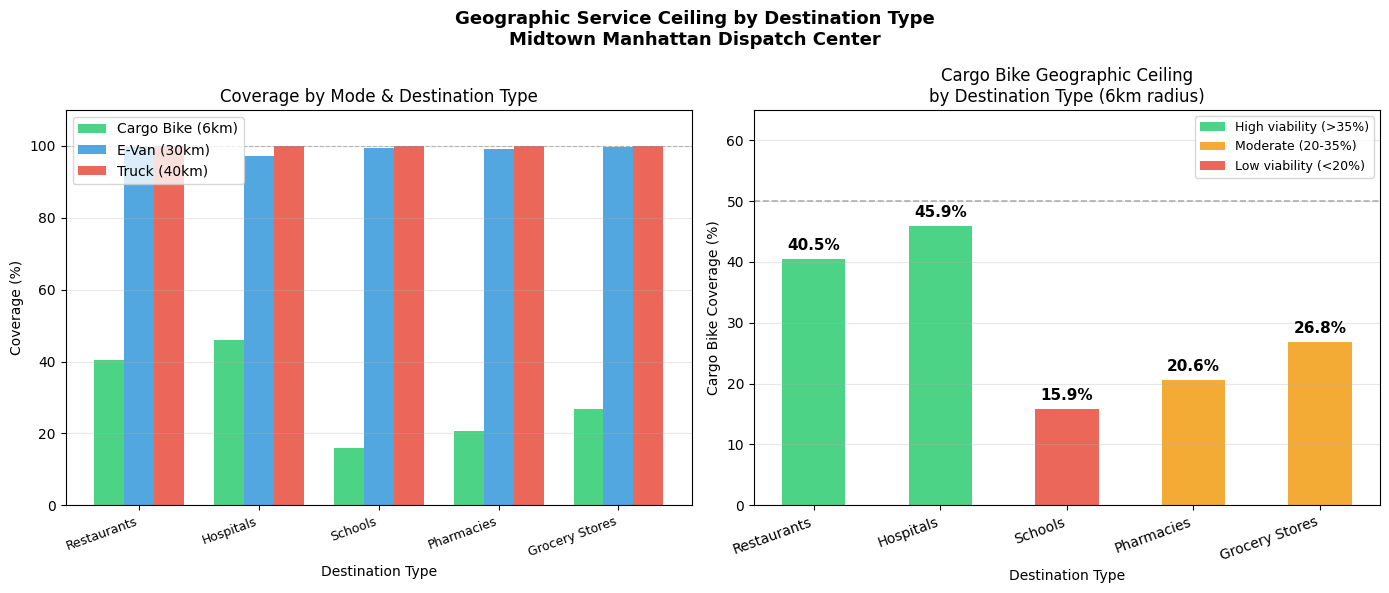

✓ Figure saved


In [25]:
# ── Section 3 Visualization: Geographic Ceiling by Destination Type ───────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Geographic Service Ceiling by Destination Type\n'
    'Midtown Manhattan Dispatch Center',
    fontsize=13, fontweight='bold'
)

colors = {
    'Cargo Bike' : '#2ecc71',
    'E-Van'      : '#3498db',
    'Truck'      : '#e74c3c'
}

destination_types = list(DATASETS.keys())
x = np.arange(len(destination_types))
width = 0.25

# ── Plot 1: Coverage % by mode across destination types ──────────────────────
ax = axes[0]
for i, (mode_name, radius) in enumerate(RADII.items()):
    values = [
        ceiling_df[
            (ceiling_df['destination_type'] == dt) &
            (ceiling_df['mode'] == mode_name)
        ]['coverage_pct'].values[0]
        for dt in destination_types
    ]
    bars = ax.bar(x + i*width, values, width,
                  label=f'{mode_name} ({radius}km)',
                  color=colors[mode_name], alpha=0.85)

ax.set_xlabel('Destination Type')
ax.set_ylabel('Coverage (%)')
ax.set_title('Coverage by Mode & Destination Type')
x = np.arange(len(destination_types))  # redefine clean
ax.set_xticks(x + width)
ax.set_xticklabels(destination_types, rotation=20, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 110)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Cargo bike ceiling only — the key finding ────────────────────────
ax2 = axes[1]
bike_values = [
    ceiling_df[
        (ceiling_df['destination_type'] == dt) &
        (ceiling_df['mode'] == 'Cargo Bike')
    ]['coverage_pct'].values[0]
    for dt in destination_types
]

bar_colors = ['#2ecc71' if v > 35 else '#f39c12' if v > 20 else '#e74c3c'
              for v in bike_values]

bars = ax2.bar(destination_types, bike_values, color=bar_colors, alpha=0.85, width=0.5)

# Annotate bars
for bar, val in zip(bars, bike_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1.2,
            alpha=0.6, label='50% reference line')
ax2.set_xlabel('Destination Type')
ax2.set_ylabel('Cargo Bike Coverage (%)')
ax2.set_title('Cargo Bike Geographic Ceiling\nby Destination Type (6km radius)')
ax2.set_ylim(0, 65)
ax2.set_xticks(np.arange(len(destination_types)))
ax2.set_xticklabels(destination_types, rotation=20, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Color legend for right plot
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', alpha=0.85, label='High viability (>35%)'),
    Patch(facecolor='#f39c12', alpha=0.85, label='Moderate (20-35%)'),
    Patch(facecolor='#e74c3c', alpha=0.85, label='Low viability (<20%)'),
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/05_geographic_ceiling_by_destination.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved")